In [1]:
# Importing the required dependencies
import random
import operator
import math
import numpy as np
import matplotlib.pyplot as plt
from deap import base, creator, tools

### Helper Functions

In [2]:
# Make a random individual.
def generate_individual(size, pos_min, pos_max):
    individual = creator.Individual(random.uniform(pos_min, pos_max) for _ in range(size))
    return individual


def mutate_differential_evolution(target, population, scale_factor):
    # Select three distinct donor vectors.
    donors = random.sample(
        [individual for individual in population if individual is not target],
        3
    )
    first, second, third = donors

    # Build V = Xr1 + F * (Xr2 - Xr3).
    donor = creator.Individual(
        first[i] + scale_factor * (second[i] - third[i])
        for i in range(len(target))
    )
    # Keep the donor inside the search bounds.
    donor[:] = [max(POS_MIN, min(POS_MAX, value)) for value in donor]
    return donor


def crossover_differential_evolution(target, donor, crossover_rate):
    # Apply binomial crossover to create the trial vector.
    forced_index = random.randrange(len(target))
    trial = creator.Individual(
        donor[i] if random.random() < crossover_rate or i == forced_index else target[i]
        for i in range(len(target))
    )
    return trial


# Fitness functions: Rosenbrock function
def evaluation_rosenbrock(individual):
    fitness = sum(100 * (individual[i] ** 2 - individual[i + 1]) ** 2 + (individual[i] - 1) ** 2 for i in range(len(individual) - 1))
    return (fitness,)

# Fitness functions: Griewank function
def evaluation_griewank(individual):
    sum_part = sum(x ** 2 / 4000 for x in individual)
    product_part = math.prod(math.cos(x / math.sqrt(i + 1)) for i, x in enumerate(individual))
    fitness = sum_part - product_part + 1
    return (fitness,)

### Configuration variables

In [3]:
# Note: Please make a change here if you want to change the number of decision variables.
# Number of variables
NUM_DECISION_VARIABLES = 50

# Population size and number of generations
POPULATION_SIZE = 50
NUM_OF_GEN = 2000

# Search space limits
POS_MIN = -30
POS_MAX = 30

# Note: Make change here if you want to change the fitness function
# Choose the fitness function here.
EVALUATION_FUNC_NAME = "evaluation_rosenbrock"

EVALUATION_FUNCTIONS = {
    "evaluation_rosenbrock": evaluation_rosenbrock,
    "evaluation_griewank": evaluation_griewank
}

# Differential Evolution settings
DE_SCALE_FACTOR = 0.5
DE_CROSSOVER_RATE = 0.9

### Toolbox

In [4]:
# Set up the fitness and individual classes.
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

# Set up the toolbox.
toolbox = base.Toolbox()

toolbox.register("individual",
                 generate_individual,
                 size=NUM_DECISION_VARIABLES,
                 pos_min=POS_MIN,
                 pos_max=POS_MAX)

# Create the population.
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("mutate", mutate_differential_evolution, scale_factor=DE_SCALE_FACTOR)

# Use the Griewank/Rosenbrock function for fitness.
toolbox.register("evaluate", EVALUATION_FUNCTIONS[EVALUATION_FUNC_NAME])

# Keep the best individuals.
toolbox.register("select", tools.selBest, k=POPULATION_SIZE)

### Differential Evolution Algorithm

In [5]:
# Run one DE experiment for every seed.
seed_list = list(range(1, 31))

# Store the results and convergence data for each seed.
results = []

# Store the convergence data for the last seed to plot the convergence graph.
convergence_data = []

for seed in seed_list:
    random.seed(seed)

    # Create the initial population and evaluate their fitness.
    current_population = toolbox.population(POPULATION_SIZE)

    for individual in current_population:
        individual.fitness.values = toolbox.evaluate(individual)

    best_fitness_by_generation = [min(individual.fitness.values[0] for individual in current_population)]
    
    for gen in range(NUM_OF_GEN):
        # Create a new population by applying mutation and crossover.
        old_population = list(current_population)

        # Select a target individual and create a donor individual.
        for index, target in enumerate(old_population):
            donor = toolbox.mutate(target, population=old_population)
            trial = crossover_differential_evolution(target, donor, DE_CROSSOVER_RATE)
            trial.fitness.values = toolbox.evaluate(trial)

            # Replace the target individual with the trial individual if it has better fitness.
            if trial.fitness.values[0] <= target.fitness.values[0]:
                current_population[index] = trial
            else:
                current_population[index] = target
        
        # Select the best individual from the current population.
        best_individual = toolbox.select(current_population, k=1)[0]
        best_fitness_by_generation.append(best_individual.fitness.values[0])
        
    best_individual = min(current_population, key=lambda individual: individual.fitness.values[0])
    results.append({"seed": seed, "best_solution": list(best_individual), "fitness": best_individual.fitness.values[0]})
    # Keep the final seed trajectory for the convergence plot.
    convergence_data = best_fitness_by_generation
    print(f"Seed : {seed}, function: {EVALUATION_FUNC_NAME}, decision variable: {NUM_DECISION_VARIABLES}, Fitness: {best_individual.fitness.values[0]:.5f}")

Seed : 1, function: evaluation_rosenbrock, decision variable: 50, Fitness: 48.53909
Seed : 2, function: evaluation_rosenbrock, decision variable: 50, Fitness: 98.73739
Seed : 3, function: evaluation_rosenbrock, decision variable: 50, Fitness: 102.49649
Seed : 4, function: evaluation_rosenbrock, decision variable: 50, Fitness: 38.23008
Seed : 5, function: evaluation_rosenbrock, decision variable: 50, Fitness: 48.55447
Seed : 6, function: evaluation_rosenbrock, decision variable: 50, Fitness: 20.56063
Seed : 7, function: evaluation_rosenbrock, decision variable: 50, Fitness: 36.89435
Seed : 8, function: evaluation_rosenbrock, decision variable: 50, Fitness: 108.16505
Seed : 9, function: evaluation_rosenbrock, decision variable: 50, Fitness: 153.05804
Seed : 10, function: evaluation_rosenbrock, decision variable: 50, Fitness: 146.57621
Seed : 11, function: evaluation_rosenbrock, decision variable: 50, Fitness: 95.94155
Seed : 12, function: evaluation_rosenbrock, decision variable: 50, Fit

### Mean and Std Deviation for Fitness

In [6]:
fitness_values = [result["fitness"] for result in results]

mean_fitness = np.mean(fitness_values)
std_fitness = np.std(fitness_values, ddof=1)

print("Mean:", mean_fitness)
print("Std:", std_fitness)

Mean: 104.04341396347735
Std: 101.78668483945249


### Plotting Convergence curve to see how for one generation fitness is reducing

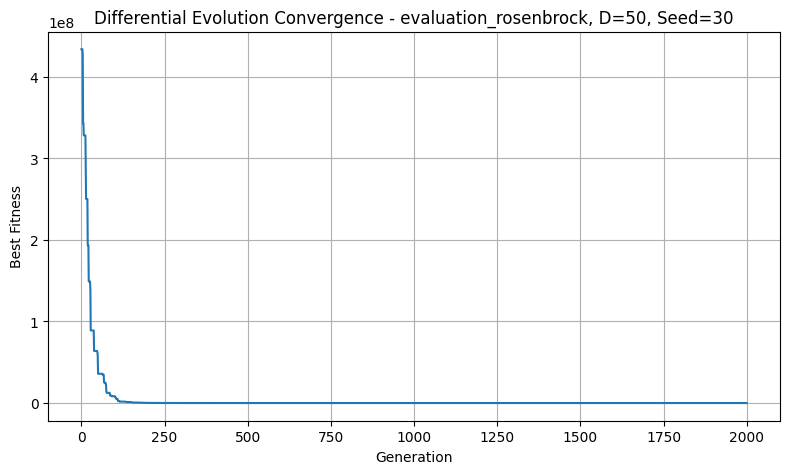

In [7]:
import matplotlib.pyplot as plt

# Note: Please change the number here if you want to see convergence curve for any generation other than 1
fitness_history = convergence_data

plt.figure(figsize=(8, 5))

plt.plot(
    range(len(fitness_history)),
    fitness_history
)

plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.title(
    f"Differential Evolution Convergence - "
    f"{EVALUATION_FUNC_NAME}, "
    f"D={NUM_DECISION_VARIABLES}, Seed={seed_list[-1]}"
)

plt.grid(True)
plt.tight_layout()

plt.show()